# 03 - Clasificacion: prediccion de abandono

Objetivo: construir y evaluar modelos supervisados para estimar la probabilidad de abandono de clientes del programa de fidelizacion AndesPlus.

## 1. Definicion del problema

Se define una ventana temporal de validacion: las variables predictoras se calculan con compras historicas hasta 90 dias antes del cierre del datamart, y `abandono = 1` si el cliente no vuelve a comprar en los ultimos 90 dias. Esta separacion evita fuga de informacion porque el modelo no usa compras futuras para crear las variables.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
IMG = ROOT / 'informe' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
VENTANA_ABANDONO_DIAS = 90

## 2. Carga y preparacion de datos

La tabla analitica se construye desde el datamart procesado, agregando comportamiento por cliente: recencia, frecuencia, monto, margen, categorias compradas, uso de promociones y canal online.

In [2]:
fact = pd.read_csv(DATA / 'fact_ventas.csv', sep=';', parse_dates=['fecha'])
clientes = pd.read_csv(DATA / 'dim_cliente.csv', sep=';', parse_dates=['fecha_alta', 'fecha_nacimiento'])
productos = pd.read_csv(DATA / 'dim_producto.csv', sep=';')
tiendas = pd.read_csv(DATA / 'dim_tienda.csv', sep=';')

df = (
    fact.merge(productos[['id_producto', 'categoria']], on='id_producto', how='left')
        .merge(tiendas[['id_tienda', 'canal']], on='id_tienda', how='left')
)

fecha_referencia = df['fecha'].max()
fecha_corte_modelo = fecha_referencia - pd.Timedelta(days=VENTANA_ABANDONO_DIAS)

historico = df[df['fecha'] <= fecha_corte_modelo].copy()
validacion_futura = df[df['fecha'] > fecha_corte_modelo].copy()

fecha_referencia, fecha_corte_modelo, len(historico), len(validacion_futura)

(Timestamp('2025-12-30 00:00:00'),
 Timestamp('2025-10-01 00:00:00'),
 52559,
 6626)

In [3]:
cliente_features = (
    historico.groupby('id_cliente')
      .agg(
          ultima_compra=('fecha', 'max'),
          primera_compra=('fecha', 'min'),
          frecuencia_boletas=('id_venta', 'nunique'),
          lineas_compra=('id_venta', 'count'),
          monto_total=('importe', 'sum'),
          margen_total=('margen', 'sum'),
          cantidad_total=('cantidad', 'sum'),
          categorias_distintas=('categoria', 'nunique'),
          compras_con_promo=('id_promocion', lambda s: (s != 'PR000').sum()),
          compras_online=('canal', lambda s: (s == 'online').sum()),
      )
      .reset_index()
)

clientes_con_compra_futura = set(validacion_futura['id_cliente'].unique())

cliente_features['recencia_dias'] = (fecha_corte_modelo - cliente_features['ultima_compra']).dt.days
cliente_features['vida_cliente_dias'] = (fecha_corte_modelo - cliente_features['primera_compra']).dt.days.clip(lower=1)
cliente_features['ticket_promedio'] = cliente_features['monto_total'] / cliente_features['frecuencia_boletas'].clip(lower=1)
cliente_features['margen_pct'] = cliente_features['margen_total'] / cliente_features['monto_total'].replace(0, np.nan)
cliente_features['promo_rate'] = cliente_features['compras_con_promo'] / cliente_features['lineas_compra'].clip(lower=1)
cliente_features['online_rate'] = cliente_features['compras_online'] / cliente_features['lineas_compra'].clip(lower=1)
cliente_features['abandono'] = (~cliente_features['id_cliente'].isin(clientes_con_compra_futura)).astype(int)

analitica = cliente_features.merge(
    clientes[['id_cliente', 'sexo', 'fecha_alta', 'segmento_programa', 'distrito']],
    on='id_cliente',
    how='left',
)
analitica['antiguedad_programa_dias'] = (fecha_corte_modelo - analitica['fecha_alta']).dt.days.clip(lower=0)
analitica['margen_pct'] = analitica['margen_pct'].fillna(0)

analitica.head()

,id_cliente,ultima_compra,primera_compra,frecuencia_boletas,lineas_compra,monto_total,margen_total,cantidad_total,categorias_distintas,compras_con_promo,...,ticket_promedio,margen_pct,promo_rate,online_rate,abandono,sexo,fecha_alta,segmento_programa,distrito,antiguedad_programa_dias
0,C00001,2024-10-12,2024-04-10,3,3,216.6900,102.0700,7,3,0,...,72.230000,0.471042,0.000000,0.0,1,M,2025-02-16,Oro,Trujillo,227
1,C00002,2025-07-27,2024-04-21,4,4,74.6375,22.2175,4,3,1,...,18.659375,0.297672,0.250000,0.0,1,M,2022-07-31,Bronce,Comas,1158
2,C00003,2025-09-27,2024-04-21,3,3,231.3580,63.2880,9,3,2,...,77.119333,0.273550,0.666667,0.0,1,M,2024-12-15,Plata,Cusco,290
3,C00005,2024-03-16,2024-03-16,1,1,4.9280,1.2180,1,1,1,...,4.928000,0.247159,1.000000,1.0,1,F,2022-04-09,Plata,Surco,1271
4,C00006,2025-07-14,2024-08-27,6,6,178.2410,45.6010,10,3,3,...,29.706833,0.255839,0.500000,0.0,0,M,2025-03-09,Bronce,Chiclayo,206


## 3. Exploracion de la variable objetivo

Se revisa el balance de clases para evaluar si el problema requiere manejo de desbalance. Los modelos se entrenan con `class_weight='balanced'` cuando aplica. Solo se consideran clientes con historial antes de la ventana futura.

In [4]:
balance = analitica['abandono'].value_counts(normalize=True).rename_axis('abandono').reset_index(name='proporcion')
balance_abs = analitica['abandono'].value_counts().rename_axis('abandono').reset_index(name='clientes')
balance.merge(balance_abs, on='abandono')

,abandono,proporcion,clientes
0,0,0.505575,2494
1,1,0.494425,2439


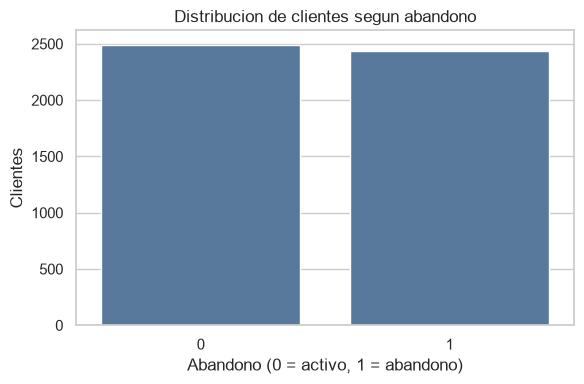

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=analitica, x='abandono', ax=ax, color='#4C78A8')
ax.set_title('Distribucion de clientes segun abandono')
ax.set_xlabel('Abandono (0 = activo, 1 = abandono)')
ax.set_ylabel('Clientes')
fig.tight_layout()
fig.savefig(IMG / 'clasificacion_balance_abandono.png', dpi=140)

## 4. Modelado

Se comparan tres modelos: Regresion Logistica, Arbol de Decision y Random Forest. La division entrenamiento/prueba es estratificada 75/25 con semilla fija 42.

In [6]:
features_numericas = [
    'recencia_dias',
    'frecuencia_boletas',
    'lineas_compra',
    'monto_total',
    'margen_total',
    'cantidad_total',
    'categorias_distintas',
    'ticket_promedio',
    'margen_pct',
    'promo_rate',
    'online_rate',
    'antiguedad_programa_dias',
    'vida_cliente_dias',
]
features_categoricas = ['sexo', 'segmento_programa']

modelo_df = pd.get_dummies(
    analitica[['id_cliente', 'abandono'] + features_numericas + features_categoricas],
    columns=features_categoricas,
    drop_first=True,
)

X = modelo_df.drop(columns=['id_cliente', 'abandono'])
y = modelo_df['abandono']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

modelos = {
    'Regresion Logistica': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'Arbol de Decision': DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=25, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
}

metricas = []
predicciones_test = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    predicciones_test[nombre] = (y_pred, y_proba)
    metricas.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
    })

metricas_df = pd.DataFrame(metricas).sort_values('roc_auc', ascending=False)
metricas_df

,modelo,accuracy,precision,recall,f1,roc_auc
2,Random Forest,0.625608,0.596354,0.750820,0.664731,0.670952
0,Regresion Logistica,0.623177,0.595269,0.742623,0.660832,0.670949
1,Arbol de Decision,0.606969,0.585266,0.703279,0.638868,0.657971


## 5. Evaluacion del mejor modelo

Se selecciona el modelo con mayor ROC-AUC. Para negocio, tambien se revisa `recall`, porque interesa detectar la mayor cantidad posible de clientes en riesgo.

In [7]:
mejor_modelo_nombre = metricas_df.iloc[0]['modelo']
mejor_modelo = modelos[mejor_modelo_nombre]
y_pred_best, y_proba_best = predicciones_test[mejor_modelo_nombre]

print('Mejor modelo:', mejor_modelo_nombre)
print('\nMatriz de confusion')
print(confusion_matrix(y_test, y_pred_best))
print('\nReporte de clasificacion')
print(classification_report(y_test, y_pred_best, digits=3))

Mejor modelo: Random Forest

Matriz de confusion
[[314 310]
 [152 458]]

Reporte de clasificacion
              precision    recall  f1-score   support

           0      0.674     0.503     0.576       624
           1      0.596     0.751     0.665       610

    accuracy                          0.626      1234
   macro avg      0.635     0.627     0.620      1234
weighted avg      0.636     0.626     0.620      1234



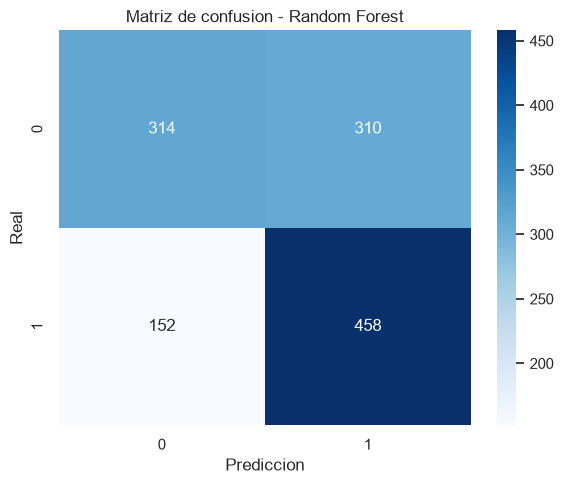

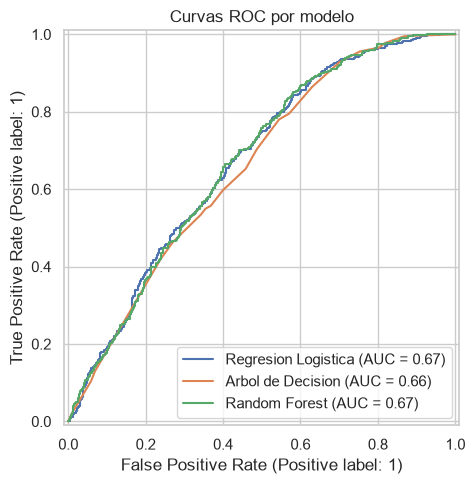

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Matriz de confusion - {mejor_modelo_nombre}')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
fig.tight_layout()
fig.savefig(IMG / 'clasificacion_matriz_confusion.png', dpi=140)

fig, ax = plt.subplots(figsize=(6, 5))
for nombre, (_, y_proba) in predicciones_test.items():
    RocCurveDisplay.from_predictions(y_test, y_proba, name=nombre, ax=ax)
ax.set_title('Curvas ROC por modelo')
fig.tight_layout()
fig.savefig(IMG / 'clasificacion_roc_auc.png', dpi=140)

## 6. Interpretacion de variables

La importancia de variables permite explicar que factores se asocian con mayor riesgo de abandono. En Random Forest y Arbol se usa importancia del modelo; en Regresion Logistica se usa magnitud absoluta de coeficientes.

,variable,importancia
2,lineas_compra,0.142730
1,frecuencia_boletas,0.132450
0,recencia_dias,0.106956
3,monto_total,0.102948
5,cantidad_total,0.091044
4,margen_total,0.088007
6,categorias_distintas,0.063629
12,vida_cliente_dias,0.053526
7,ticket_promedio,0.052254
11,antiguedad_programa_dias,0.047996


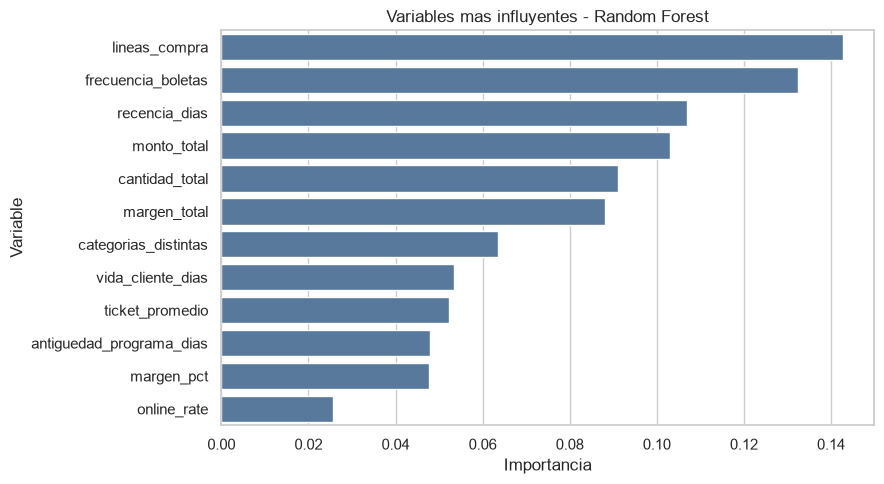

In [9]:
if mejor_modelo_nombre == 'Regresion Logistica':
    coefs = mejor_modelo.named_steps['model'].coef_[0]
    importancia = pd.DataFrame({'variable': X.columns, 'importancia': np.abs(coefs)})
else:
    importancia = pd.DataFrame({'variable': X.columns, 'importancia': mejor_modelo.feature_importances_})

importancia = importancia.sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importancia.head(12), x='importancia', y='variable', ax=ax, color='#4C78A8')
ax.set_title(f'Variables mas influyentes - {mejor_modelo_nombre}')
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')
fig.tight_layout()
fig.savefig(IMG / 'clasificacion_importancia_variables.png', dpi=140)

importancia.head(12)

## 7. Predicciones para Power BI

Se entrena el mejor modelo con toda la base y se exporta la probabilidad de abandono de cada cliente. Esto permite crear una pagina de Power BI enfocada en retencion.

In [10]:
mejor_modelo.fit(X, y)
probabilidades = mejor_modelo.predict_proba(X)[:, 1]

predicciones = analitica[[
    'id_cliente',
    'recencia_dias',
    'frecuencia_boletas',
    'monto_total',
    'ticket_promedio',
    'categorias_distintas',
    'promo_rate',
    'online_rate',
    'segmento_programa',
    'abandono',
]].copy()
predicciones['probabilidad_abandono'] = probabilidades
predicciones['nivel_riesgo'] = pd.cut(
    predicciones['probabilidad_abandono'],
    bins=[-0.01, 0.40, 0.70, 1.0],
    labels=['Bajo', 'Medio', 'Alto'],
)
predicciones = predicciones.sort_values('probabilidad_abandono', ascending=False)

predicciones.to_csv(DATA / 'predicciones_abandono.csv', sep=';', index=False, encoding='utf-8')
metricas_df.to_csv(DATA / 'metricas_clasificacion.csv', sep=';', index=False, encoding='utf-8')
importancia.to_csv(DATA / 'importancia_variables_clasificacion.csv', sep=';', index=False, encoding='utf-8')

predicciones.head(10)

,id_cliente,recencia_dias,frecuencia_boletas,monto_total,ticket_promedio,categorias_distintas,promo_rate,online_rate,segmento_programa,abandono,probabilidad_abandono,nivel_riesgo
2929,C02966,620,1,143.75,143.75,1,0.0,0.0,Plata,1,0.741294,Alto
1288,C01309,623,1,136.25,136.25,1,0.0,0.0,Plata,1,0.731923,Alto
686,C00700,528,1,19.31,19.31,1,0.0,0.0,Bronce,1,0.724403,Alto
1879,C01907,620,1,67.71,67.71,1,0.0,0.0,Plata,1,0.718115,Alto
3343,C03388,546,1,135.10,135.10,1,0.0,0.0,Bronce,1,0.716679,Alto
1737,C01762,600,1,55.32,55.32,1,0.0,0.0,Bronce,1,0.716647,Alto
573,C00586,555,1,38.70,38.70,1,0.0,0.0,Plata,1,0.714059,Alto
149,C00156,600,1,127.60,127.60,1,0.0,0.0,Oro,1,0.713488,Alto
829,C00845,574,1,48.24,48.24,1,0.0,0.0,Bronce,0,0.713469,Alto
2605,C02637,612,1,84.75,84.75,1,0.0,0.0,Bronce,1,0.712436,Alto


## 8. Recomendaciones de retencion

Las acciones se deben priorizar por nivel de riesgo y valor del cliente.

In [11]:
resumen_riesgo = (
    predicciones.groupby('nivel_riesgo', observed=True)
    .agg(
        clientes=('id_cliente', 'count'),
        probabilidad_promedio=('probabilidad_abandono', 'mean'),
        venta_acumulada=('monto_total', 'sum'),
        ticket_promedio=('ticket_promedio', 'mean'),
    )
    .reset_index()
)

md = f"# Resumen de clasificacion de abandono\n\n"
md += f"- Ventana historica de variables: compras hasta {fecha_corte_modelo.date()}.\n"
md += f"- Definicion de abandono: cliente sin compras entre {fecha_corte_modelo.date()} y {fecha_referencia.date()}.\n"
md += f"- Mejor modelo: {mejor_modelo_nombre}.\n"
md += f"- ROC-AUC del mejor modelo en prueba: {metricas_df.iloc[0]['roc_auc']:.3f}.\n"
md += f"- Recall del mejor modelo en prueba: {metricas_df.iloc[0]['recall']:.3f}.\n\n"
md += "## Acciones recomendadas\n\n"
md += "1. Priorizar clientes de riesgo alto con monto historico elevado para campanas de retencion personalizadas.\n"
md += "2. Usar descuentos selectivos solo en clientes con alta probabilidad de abandono y buena contribucion historica.\n"
md += "3. Activar comunicaciones para clientes con alta recencia y baja frecuencia antes de que pasen a riesgo alto.\n"
md += "4. Analizar por segmento AndesPlus para adaptar beneficios segun valor y comportamiento.\n"

(ROOT / 'informe' / 'resumen_clasificacion.md').write_text(md, encoding='utf-8')
resumen_riesgo

,nivel_riesgo,clientes,probabilidad_promedio,venta_acumulada,ticket_promedio
0,Bajo,1018,0.228026,1.419197e+06,43.244372
1,Medio,3881,0.568634,8.658805e+05,43.207558
2,Alto,34,0.709675,2.543490e+03,66.997838


## 9. Salidas generadas

- `data/processed/predicciones_abandono.csv`: clientes con probabilidad y nivel de riesgo.
- `data/processed/metricas_clasificacion.csv`: comparacion de modelos.
- `data/processed/importancia_variables_clasificacion.csv`: variables influyentes.
- `informe/resumen_clasificacion.md`: interpretacion y acciones.
- Imagenes en `informe/img/`: balance de clases, matriz de confusion, ROC-AUC e importancia de variables.

Para Power BI, importar `predicciones_abandono.csv` y relacionarlo con `dim_cliente` por `id_cliente`.